In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [21]:

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

columns = [
    'checking_account', 'duration', 'credit_history', 'purpose', 'credit_amount',
    'savings_account', 'employment_since', 'installment_rate', 'personal_status_sex',
    'other_debtors', 'residence_since', 'property', 'age', 'other_installment_plans',
    'housing', 'existing_credits', 'job', 'num_dependents', 'telephone',
    'foreign_worker', 'target'
]

df = pd.read_csv(url, sep=' ', header=None, names=columns)

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (1000, 21)


,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,residence_since,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201,2


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   checking_account         1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   savings_account          1000 non-null   object
 6   employment_since         1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

In [23]:
df.describe()

,duration,credit_amount,installment_rate,residence_since,age,existing_credits,num_dependents,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


In [24]:
df['target'].value_counts()

,count
target,
1,700
2,300


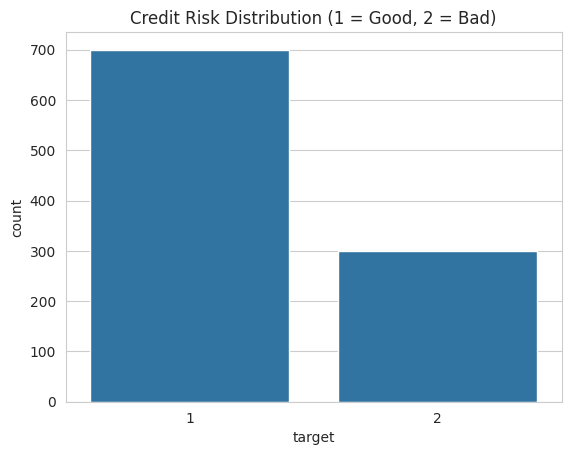

In [25]:
sns.countplot(x='target', data=df)
plt.title('Credit Risk Distribution (1 = Good, 2 = Bad)')
plt.show()

In [26]:
checking_account_map = {
    'A11': '< 0 DM', 'A12': '0-200 DM', 'A13': '>= 200 DM', 'A14': 'no checking account'
}
credit_history_map = {
    'A30': 'no credits/all paid', 'A31': 'all paid (this bank)',
    'A32': 'existing paid duly', 'A33': 'delay in past', 'A34': 'critical account'
}
purpose_map = {
    'A40': 'new car', 'A41': 'used car', 'A42': 'furniture/equipment',
    'A43': 'radio/TV', 'A44': 'domestic appliances', 'A45': 'repairs',
    'A46': 'education', 'A48': 'retraining', 'A49': 'business', 'A410': 'others'
}
savings_map = {
    'A61': '< 100 DM', 'A62': '100-500 DM', 'A63': '500-1000 DM',
    'A64': '>= 1000 DM', 'A65': 'unknown/none'
}
employment_map = {
    'A71': 'unemployed', 'A72': '< 1 year', 'A73': '1-4 years',
    'A74': '4-7 years', 'A75': '>= 7 years'
}
personal_status_map = {
    'A91': 'male: divorced/separated', 'A92': 'female: divorced/separated/married',
    'A93': 'male: single', 'A94': 'male: married/widowed', 'A95': 'female: single'
}
housing_map = {
    'A151': 'rent', 'A152': 'own', 'A153': 'for free'
}
job_map = {
    'A171': 'unemployed/unskilled', 'A172': 'unskilled resident',
    'A173': 'skilled employee', 'A174': 'management/self-employed'
}

df['checking_account'] = df['checking_account'].map(checking_account_map)
df['credit_history'] = df['credit_history'].map(credit_history_map)
df['purpose'] = df['purpose'].map(purpose_map)
df['savings_account'] = df['savings_account'].map(savings_map)
df['employment_since'] = df['employment_since'].map(employment_map)
df['personal_status_sex'] = df['personal_status_sex'].map(personal_status_map)
df['housing'] = df['housing'].map(housing_map)
df['job'] = df['job'].map(job_map)

df['target'] = df['target'].map({1: 0, 2: 1})

df.head()

,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,residence_since,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target
0,< 0 DM,6,critical account,radio/TV,1169,unknown/none,>= 7 years,4,male: single,A101,4,A121,67,A143,own,2,skilled employee,1,A192,A201,0
1,0-200 DM,48,existing paid duly,radio/TV,5951,< 100 DM,1-4 years,2,female: divorced/separated/married,A101,2,A121,22,A143,own,1,skilled employee,1,A191,A201,1
2,no checking account,12,critical account,education,2096,< 100 DM,4-7 years,2,male: single,A101,3,A121,49,A143,own,1,unskilled resident,2,A191,A201,0
3,< 0 DM,42,existing paid duly,furniture/equipment,7882,< 100 DM,4-7 years,2,male: single,A103,4,A122,45,A143,for free,1,skilled employee,2,A191,A201,0
4,< 0 DM,24,delay in past,new car,4870,< 100 DM,1-4 years,3,male: single,A101,4,A124,53,A143,for free,2,skilled employee,2,A191,A201,1


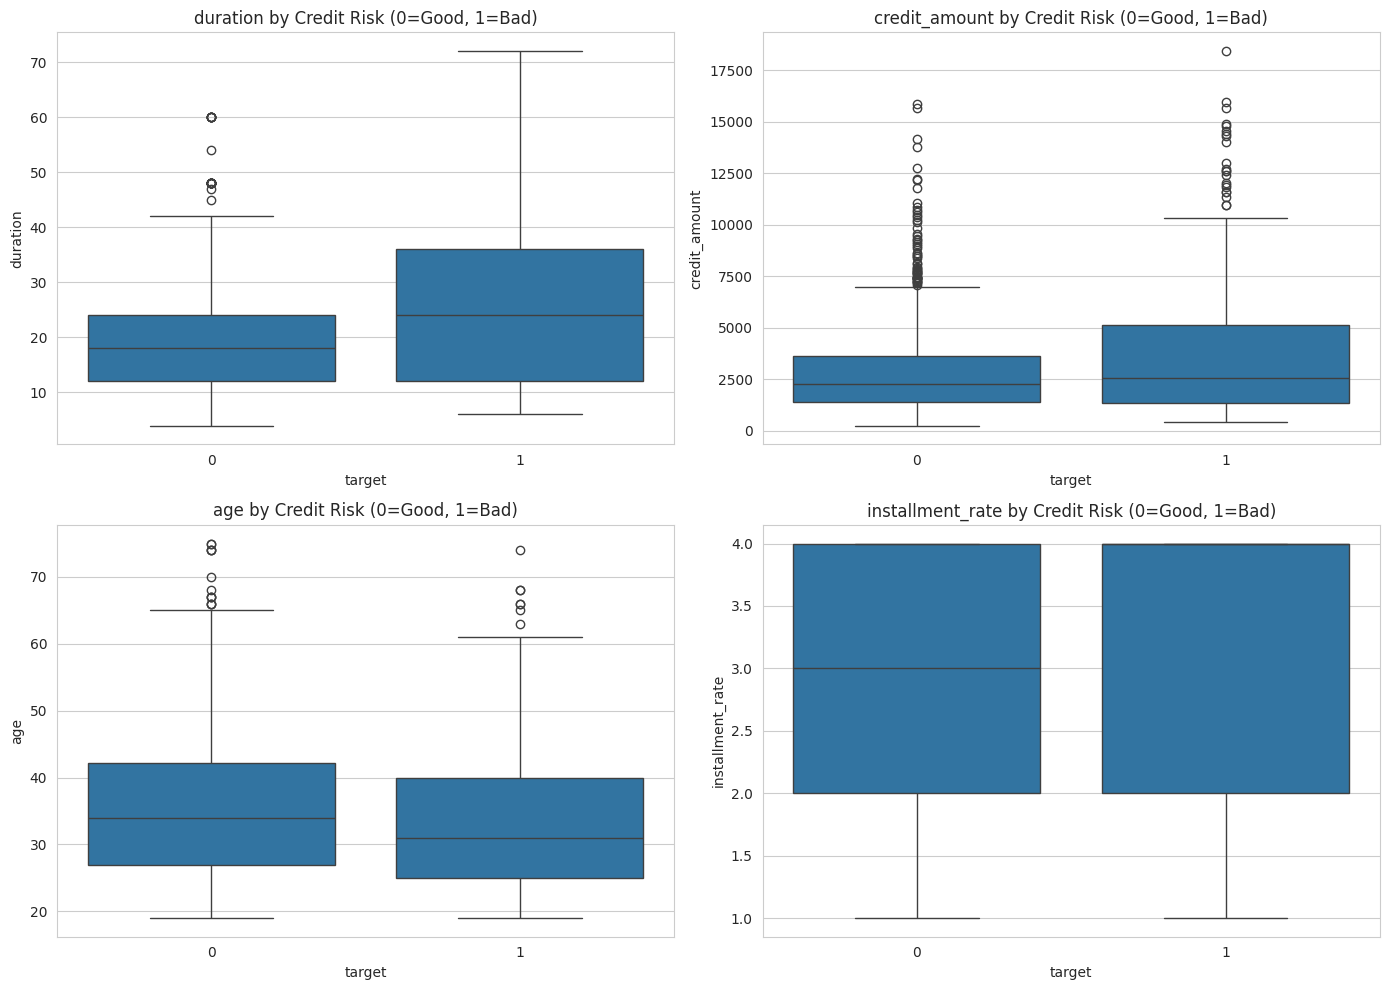

In [27]:

numeric_cols = ['duration', 'credit_amount', 'age', 'installment_rate']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x='target', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} by Credit Risk (0=Good, 1=Bad)')

plt.tight_layout()
plt.show()

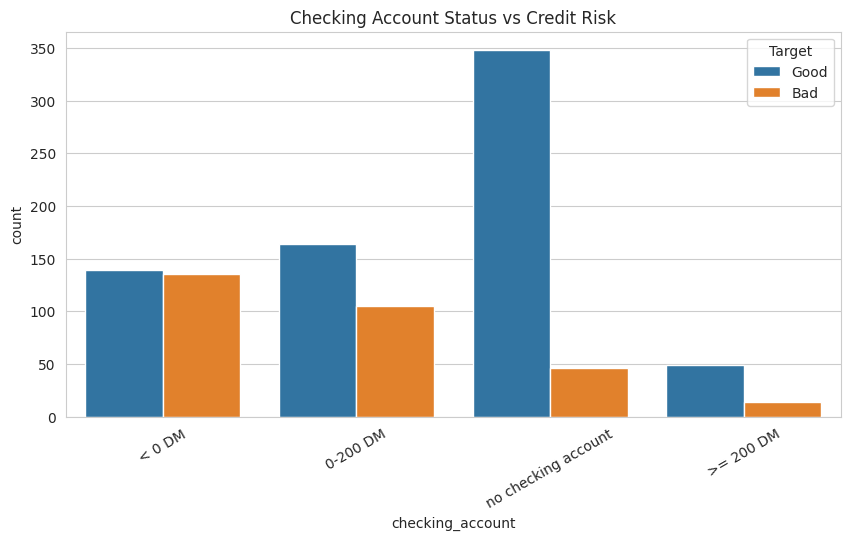

In [28]:
plt.figure(figsize=(10, 5))
sns.countplot(x='checking_account', hue='target', data=df)
plt.title('Checking Account Status vs Credit Risk')
plt.xticks(rotation=30)
plt.legend(title='Target', labels=['Good', 'Bad'])
plt.show()

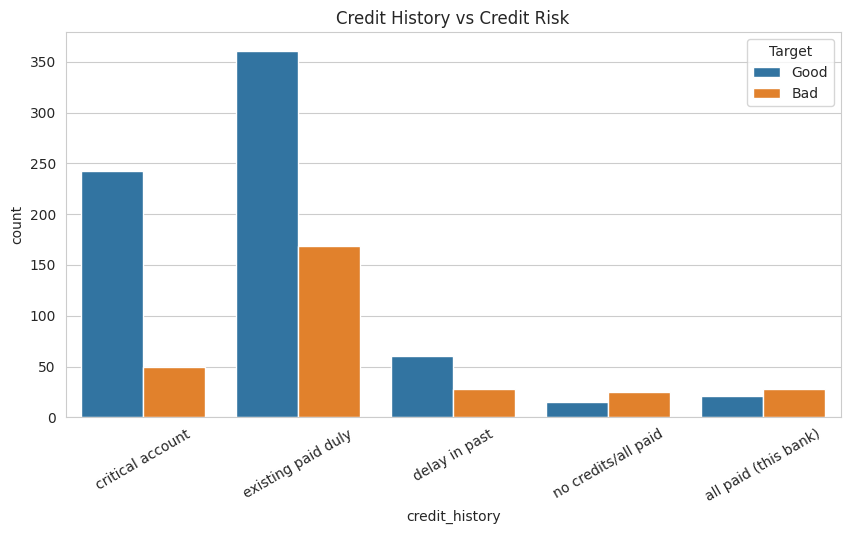

In [29]:
plt.figure(figsize=(10, 5))
sns.countplot(x='credit_history', hue='target', data=df)
plt.title('Credit History vs Credit Risk')
plt.xticks(rotation=30)
plt.legend(title='Target', labels=['Good', 'Bad'])
plt.show()

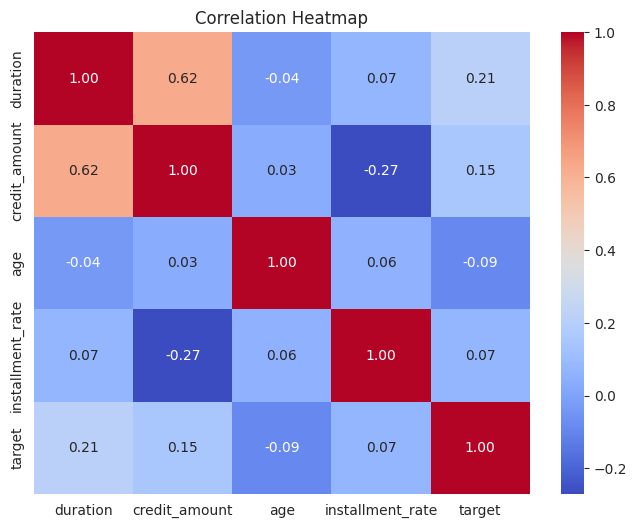

In [30]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols + ['target']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [31]:

df['credit_per_month'] = df['credit_amount'] / df['duration']

df['age_group'] = pd.cut(df['age'], bins=[18, 25, 35, 45, 60, 100],
                           labels=['18-25', '26-35', '36-45', '46-60', '60+'])


df['risky_checking'] = df['checking_account'].apply(
    lambda x: 1 if x in ['< 0 DM', '0-200 DM'] else 0
)

df['long_duration'] = (df['duration'] > df['duration'].median()).astype(int)


df['high_amount_long_term'] = ((df['credit_amount'] > df['credit_amount'].median()) &
                                  (df['duration'] > df['duration'].median())).astype(int)

df[['credit_per_month', 'age_group', 'risky_checking', 'long_duration', 'high_amount_long_term']].head()

,credit_per_month,age_group,risky_checking,long_duration,high_amount_long_term
0,194.833333,60+,1,0,0
1,123.979167,18-25,1,1,1
2,174.666667,46-60,0,0,0
3,187.666667,36-45,1,1,1
4,202.916667,46-60,1,1,1


In [32]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns to encode:", categorical_cols)

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Categorical columns to encode: ['checking_account', 'credit_history', 'purpose', 'savings_account', 'employment_since', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker', 'age_group']
Shape after encoding: (1000, 57)


,duration,credit_amount,installment_rate,residence_since,age,existing_credits,num_dependents,target,credit_per_month,risky_checking,long_duration,high_amount_long_term,checking_account_< 0 DM,checking_account_>= 200 DM,checking_account_no checking account,credit_history_critical account,credit_history_delay in past,credit_history_existing paid duly,credit_history_no credits/all paid,purpose_domestic appliances,purpose_education,purpose_furniture/equipment,purpose_new car,purpose_others,purpose_radio/TV,purpose_repairs,purpose_retraining,purpose_used car,savings_account_500-1000 DM,savings_account_< 100 DM,savings_account_>= 1000 DM,savings_account_unknown/none,employment_since_4-7 years,employment_since_< 1 year,employment_since_>= 7 years,employment_since_unemployed,personal_status_sex_male: divorced/separated,personal_status_sex_male: married/widowed,personal_status_sex_male: single,other_debtors_A102,other_debtors_A103,property_A122,property_A123,property_A124,other_installment_plans_A142,other_installment_plans_A143,housing_own,housing_rent,job_skilled employee,job_unemployed/unskilled,job_unskilled resident,telephone_A192,foreign_worker_A202,age_group_26-35,age_group_36-45,age_group_46-60,age_group_60+
0,6,1169,4,4,67,2,1,0,194.833333,1,0,0,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False,True,True,False,True,False,False,True,False,False,False,False,True
1,48,5951,2,2,22,1,1,1,123.979167,1,1,1,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,True,False,False,False,False,False,False,False,False
2,12,2096,2,3,49,1,2,0,174.666667,0,0,0,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False,False,False,True,False,False,False,False,True,False
3,42,7882,2,4,45,1,2,0,187.666667,1,1,1,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,True,True,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False
4,24,4870,3,4,53,2,2,1,202.916667,1,1,1,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,True,False,False,False,False,False,False,True,False


In [33]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train target distribution:\n", y_train.value_counts(normalize=True))
print("Test target distribution:\n", y_test.value_counts(normalize=True))

Train shape: (800, 56)
Test shape: (200, 56)
Train target distribution:
 target
0    0.7
1    0.3
Name: proportion, dtype: float64
Test target distribution:
 target
0    0.7
1    0.3
Name: proportion, dtype: float64


In [34]:
!pip install imbalanced-learn -q

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_balanced.value_counts().to_dict())

Before SMOTE: {0: 560, 1: 240}
After SMOTE: {1: 560, 0: 560}


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
}

trained_models = {}
for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train_balanced)
    else:
        model.fit(X_train_balanced, y_train_balanced)
    trained_models[name] = model
    print(f"{name} trained.")

Logistic Regression trained.
Decision Tree trained.
Random Forest trained.


In [36]:
from sklearn.metrics import (classification_report, confusion_matrix,
                               roc_auc_score, roc_curve, precision_recall_curve)

results = {}

for name, model in trained_models.items():
    if name == 'Logistic Regression':
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    results[name] = {'y_pred': y_pred, 'y_proba': y_proba, 'auc': auc}

    print(f"\n{'='*50}")
    print(f"{name}  |  ROC-AUC: {auc:.3f}")
    print('='*50)
    print(classification_report(y_test, y_pred, target_names=['Good', 'Bad']))


Logistic Regression  |  ROC-AUC: 0.749
              precision    recall  f1-score   support

        Good       0.80      0.79      0.79       140
         Bad       0.52      0.53      0.52        60

    accuracy                           0.71       200
   macro avg       0.66      0.66      0.66       200
weighted avg       0.71      0.71      0.71       200


Decision Tree  |  ROC-AUC: 0.632
              precision    recall  f1-score   support

        Good       0.76      0.75      0.76       140
         Bad       0.44      0.45      0.44        60

    accuracy                           0.66       200
   macro avg       0.60      0.60      0.60       200
weighted avg       0.66      0.66      0.66       200


Random Forest  |  ROC-AUC: 0.769
              precision    recall  f1-score   support

        Good       0.82      0.87      0.84       140
         Bad       0.65      0.55      0.59        60

    accuracy                           0.78       200
   macro avg       0

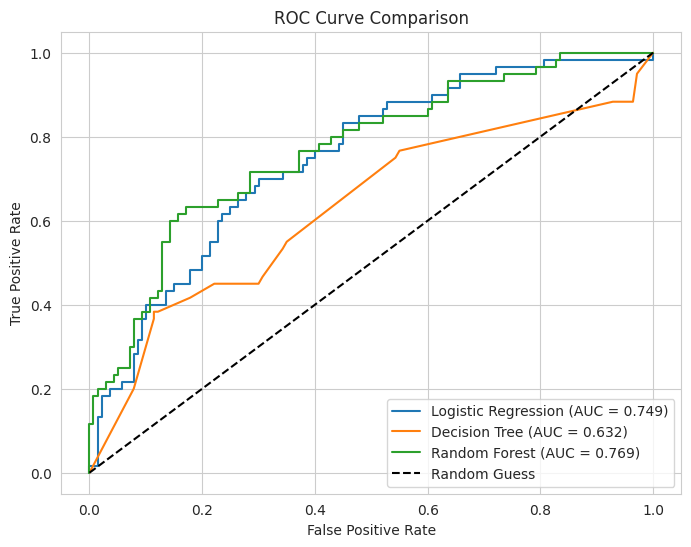

In [37]:
plt.figure(figsize=(8, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

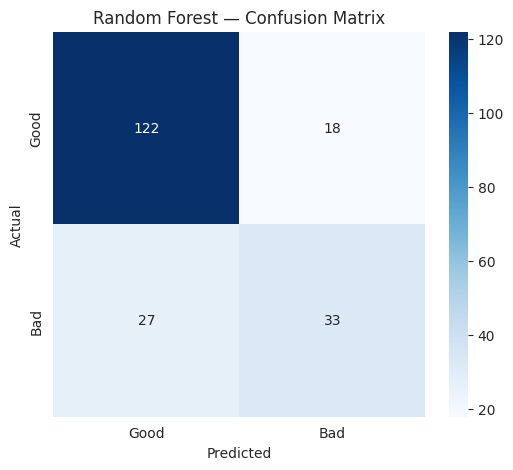

In [38]:

best_model_name = 'Random Forest'
best_pred = results[best_model_name]['y_pred']

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'])
plt.title(f'{best_model_name} — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

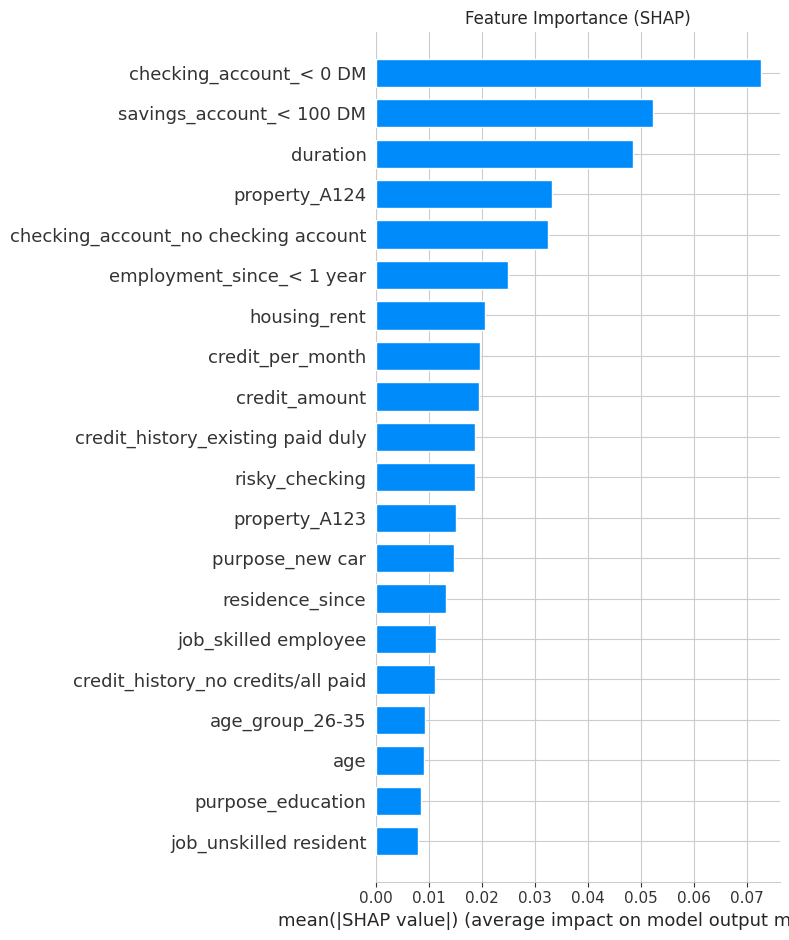

In [39]:
!pip install shap -q
import shap

explainer = shap.TreeExplainer(trained_models['Random Forest'])
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values[:,:,1], X_test, plot_type='bar', show=False)
plt.title('Feature Importance (SHAP)')
plt.tight_layout()
plt.show()

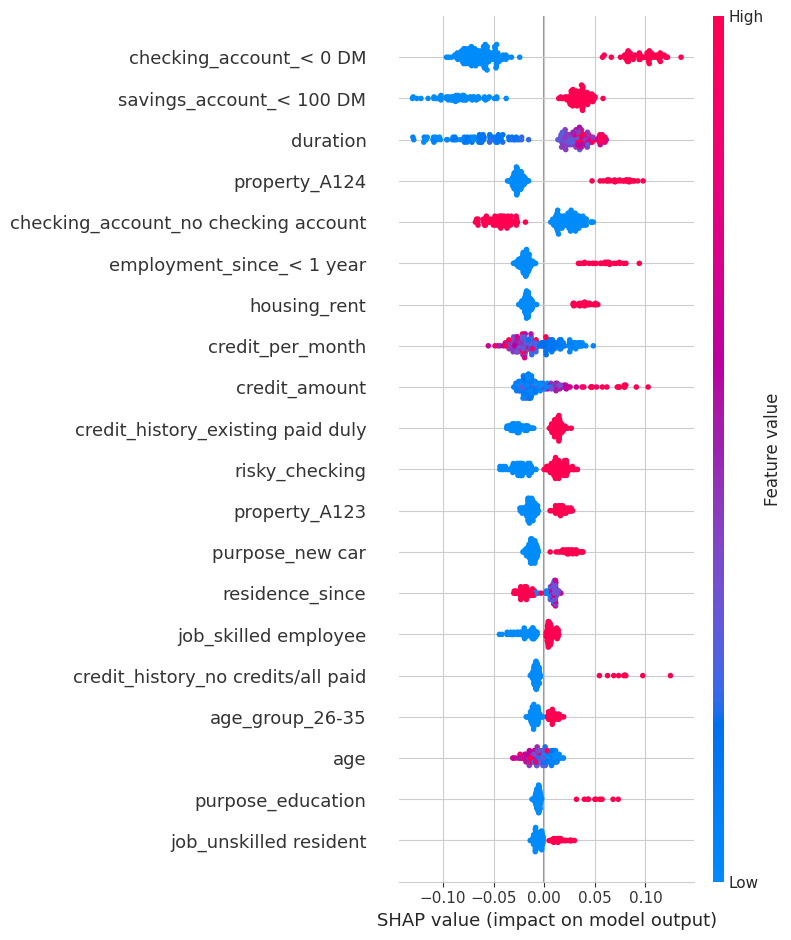

In [40]:
shap.summary_plot(shap_values[:,:,1], X_test, show=False)
plt.tight_layout()
plt.show()

In [41]:
import joblib

joblib.dump(trained_models['Random Forest'], 'credit_scoring_rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and scaler saved!")

Model and scaler saved!
